<a href="https://colab.research.google.com/github/chioreanufilip/lightDeepfakesSystem/blob/colab/Evaluation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
#!pip install facenet-pytorch

In [ ]:
#!pip install mediapipe

In [ ]:
#!pip install retina-face

In [ ]:
#!pip install pandas matplotlib seaborn

In [ ]:
# Wir installieren die Detektoren, aber zwingen das System,
# eine alte Numpy-Version (< 2) zu verwenden!
!pip install facenet-pytorch mediapipe retina-face "numpy<2" pandas matplotlib seaborn

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.0/61.0 kB 1.7 MB/s eta 0:00:00
INFO: pip is looking at multiple versions of opencv-python to determine which version is compatible with other requirements. This could take a while.
INFO: pip is looking at multiple versions of opencv-contrib-python to determine which version is compatible with other requirements. This could take a while.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.9/1.9 MB 23.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.4/12.4 MB 62.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.0/18.0 MB 41.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 135.8/135.8 kB 8.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.0/63.0 MB 8.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.5/4.5 MB 46.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 755.5/755.5 MB 777.5 kB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 410.6/410.6 MB 4.

In [ ]:
#!pip install --force-reinstall mediapipe "numpy<2"

In [ ]:
# Installation der Detektoren
# Für MTCNN

# Entfernen Sie die ursprünglichen !pip install Zeilen aus dieser Zelle,
# da die Installationen jetzt in einer dedizierten Zelle am Anfang zusammengefasst sind.


import torch
import torch.nn as nn
from torchvision import models, transforms
from PIL import Image
import cv2
import os
os.environ['TF_USE_LEGACY_KERAS'] = '1'
import time
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from google.colab import drive
from facenet_pytorch import MTCNN
import urllib.request
import mediapipe as mp
from mediapipe.tasks import python
from mediapipe.tasks.python import vision
from retinaface import RetinaFace
import zipfile

# Drive mounten
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# 1. Modell Architektur definieren (muss exakt wie beim Training sein)
# model = models.mobilenet_v3_small(pretrained=False)
# model.classifier[3] = nn.Linear(model.classifier[3].in_features, 2)
# model.load_state_dict(torch.load('/content/drive/MyDrive/DeepfakeDetection/mobileNetV3_model.pth'))
# model = model.to(device)
# model.eval()

# import zipfile
# import os
# import shutil

# # 1. Pfad zu deiner gesplitteten Datei (Passe den Pfad an, falls er in DeepfakeDetection liegt)
# zip_path = '/content/drive/MyDrive/DeepfakeDetection/dfdc_images_split.zip'
# # Falls du sie in einem Unterordner hast, z.B.: '/content/drive/MyDrive/DeepfakeDetection/dfdc_images_split.zip'

# output_base = '/content/test_images'
# final_test_dir = f'{output_base}/raw_test_images'

# # 2. Alten Ordner löschen, falls vorhanden, für einen sauberen Start
# print("🧹 Säubere alte Test-Ordner...")
# if os.path.exists(output_base):
#     shutil.rmtree(output_base)
# os.makedirs(final_test_dir, exist_ok=True)

# print(f"📦 Entpacke isolierte Test-Bilder aus {zip_path}...")

# # 3. ZIP öffnen und NUR den 'test'-Ordner extrahieren
# try:
#     with zipfile.ZipFile(zip_path, 'r') as z:
#         # Finde alle Dateien, die im 'test' Ordner liegen
#         test_files = [f for f in z.namelist() if f.startswith('test/')]

#         if not test_files:
#             print("❌ Fehler: Kein 'test'-Ordner im ZIP gefunden! Hast du die richtige Datei angegeben?")
#         else:
#             # Entpacke nur die Test-Dateien temporär
#             z.extractall('/content/temp_extract', members=test_files)

#             # Verschiebe REAL und FAKE an den richtigen Platz für dein Skript
#             shutil.move('/content/temp_extract/test/REAL', f'{final_test_dir}/REAL')
#             shutil.move('/content/temp_extract/test/FAKE', f'{final_test_dir}/FAKE')

#             # Temporären Ordner löschen
#             shutil.rmtree('/content/temp_extract')

#             # 4. Kontrolle: Wie viele Bilder haben wir?
#             real_count = len(os.listdir(f'{final_test_dir}/REAL'))
#             fake_count = len(os.listdir(f'{final_test_dir}/FAKE'))

#             print(f"🚀 FERTIG! Deine unberührten Testbilder liegen bereit.")
#             print(f"📊 Geladen zur Evaluierung: {real_count} REAL und {fake_count} FAKE Bilder.")
# except FileNotFoundError:
#     print(f"❌ Datei {zip_path} nicht gefunden! Bitte überprüfe den Dateipfad zu deinem Google Drive.")

# print("Modell geladen und Bilder entpackt.")
# import zipfile
# import os
# import shutil
# import torch
# import torch.nn as nn
# from torchvision import models

# --- 1. MODELL-LADEN (Beispiel MobileNetV3) ---
# WICHTIG: Wenn du ResNet oder EfficientNet testest, musst du diesen Block anpassen!
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
#MobileNet
model = models.mobilenet_v3_small(weights=None) # pretrained=False ist veraltet
model.classifier[3] = nn.Linear(model.classifier[3].in_features, 2)
model.load_state_dict(torch.load('/content/drive/MyDrive/DeepfakeDetection/mobileNetV3_model.pth'))
model = model.to(device)
model.eval()

#Resnet
# model = models.resnet18(weights=None)
# num_ftrs = model.fc.in_features
# model.fc = nn.Linear(num_ftrs, 2)
# model.load_state_dict(torch.load('/content/drive/MyDrive/DeepfakeDetection/resNet_model.pth'))
# model = model.to(device)
# model.eval()

#EfficientNet
# model = models.efficientnet_b0(weights=None)
# num_ftrs = model.classifier[1].in_features
# model.classifier[1] = nn.Linear(num_ftrs, 2)
# model.load_state_dict(torch.load('/content/drive/MyDrive/DeepfakeDetection/effNet_model.pth'))
# model = model.to(device)
# model.eval()

# --- 2. PFADE DEFINIEREN ---
zip_path = '/content/drive/MyDrive/DeepfakeDetection/dfdc_images_split.zip'
output_base = '/content/test_images'
final_test_dir = f'{output_base}/raw_test_images'

# --- 3. SÄUBERN ---
print("🧹 Säubere alte Test-Ordner...")
if os.path.exists(output_base):
    shutil.rmtree(output_base)
os.makedirs(f'{final_test_dir}/REAL', exist_ok=True)
os.makedirs(f'{final_test_dir}/FAKE', exist_ok=True)

# --- 4. GEZIELTES ENTPACKEN (Nur 500 pro Klasse) ---
print(f"📦 Extrahiere jeweils 500 Bilder aus {zip_path}...")

try:
    with zipfile.ZipFile(zip_path, 'r') as z:
        all_files = z.namelist()

        # Listen für REAL und FAKE im Test-Ordner erstellen
        test_real = [f for f in all_files if f.startswith('test/REAL/') and f.lower().endswith(('.png', '.jpg', '.jpeg'))]
        test_fake = [f for f in all_files if f.startswith('test/FAKE/') and f.lower().endswith(('.png', '.jpg', '.jpeg'))]

        # Auf 500 begrenzen
        selected_real = test_real[:500]
        selected_fake = test_fake[:500]

        if len(selected_real) < 500 or len(selected_fake) < 500:
            print(f"⚠️ Warnung: Nicht genug Bilder gefunden! (Gefunden: REAL {len(test_real)}, FAKE {len(test_fake)})")

        # Bilder einzeln entpacken
        for f in selected_real:
            # Extrahiert die Datei und legt sie direkt in unseren Zielordner
            filename = os.path.basename(f)
            with z.open(f) as source, open(os.path.join(f'{final_test_dir}/REAL', filename), "wb") as target:
                shutil.copyfileobj(source, target)

        for f in selected_fake:
            filename = os.path.basename(f)
            with z.open(f) as source, open(os.path.join(f'{final_test_dir}/FAKE', filename), "wb") as target:
                shutil.copyfileobj(source, target)

    # Kontrolle
    print(f"🚀 FERTIG!")
    print(f"📊 Im Ordner liegen jetzt: {len(os.listdir(f'{final_test_dir}/REAL'))} REAL Bilder.")
    print(f"📊 Im Ordner liegen jetzt: {len(os.listdir(f'{final_test_dir}/FAKE'))} FAKE Bilder.")

except FileNotFoundError:
    print(f"❌ Datei {zip_path} nicht gefunden!")

print("Modell bereit für die 1000-Bilder-Evaluierung.")

🧹 Säubere alte Test-Ordner...
📦 Entpacke isolierte Test-Bilder aus /content/drive/MyDrive/DeepfakeDetection/dfdc_images_split.zip...
🚀 FERTIG! Deine unberührten Testbilder liegen bereit.
📊 Geladen zur Evaluierung: 1349 REAL und 1348 FAKE Bilder.
Modell geladen und Bilder entpackt.


In [ ]:
# Initialisierung der Detektoren
mtcnn = MTCNN(keep_all=False, device=device)
#print("Lade BlazeFace Modell herunter...")
urllib.request.urlretrieve(
    "https://storage.googleapis.com/mediapipe-models/face_detector/blaze_face_short_range/float16/1/blaze_face_short_range.tflite",
    "blaze_face.tflite"
)

base_options = python.BaseOptions(model_asset_path='blaze_face.tflite')
options = vision.FaceDetectorOptions(base_options=base_options, min_detection_confidence=0.5)
blazeface = vision.FaceDetector.create_from_options(options)

def get_face_crop(img_path, detector_type):
    img_bgr = cv2.imread(img_path)
    img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
    h, w, _ = img_rgb.shape

    if detector_type == 'MTCNN':
        face = mtcnn(img_rgb) # Gibt bereits ein Tensor-Crop zurück
        return face # (3, 160, 160)

    elif detector_type == 'BlazeFace':
        # Neues MediaPipe Format
        mp_image = mp.Image(image_format=mp.ImageFormat.SRGB, data=img_rgb)
        detection_result = blazeface.detect(mp_image)

        if detection_result.detections:
            # Die Bounding Box des ersten Gesichts holen
            bbox = detection_result.detections[0].bounding_box
            x = max(0, bbox.origin_x)
            y = max(0, bbox.origin_y)
            bw = bbox.width
            bh = bbox.height

            # Bild ausschneiden
            face_img = img_rgb[y:y+bh, x:x+bw]
            if face_img.size > 0:
                return face_img

    elif detector_type == 'RetinaFace':
        resp = RetinaFace.detect_faces(img_path)
        if isinstance(resp, dict) and 'face_1' in resp:
            bbox = resp['face_1']['facial_area']
            face_img = img_rgb[bbox[1]:bbox[3], bbox[0]:bbox[2]]
            return face_img

    return None

# Bild-Transformations-Pipeline für das Modell
test_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

In [ ]:
import torch.nn.functional as F

detectors = ['MTCNN', 'BlazeFace', 'RetinaFace']
base_path = '/content/test_images/raw_test_images'
classes = ['REAL', 'FAKE']

results_list = []

# NEU: Ein Dictionary, das für JEDEN Detektor eigene Listen anlegt!
detailed_results = {
    det: {'y_true': [], 'y_pred': [], 'y_probs': []} for det in detectors
}

for det_name in detectors:
    print(f"Teste Pipeline mit: {det_name}...")
    correct = 0
    total = 0
    start_time = time.time()

    for label_idx, label_name in enumerate(classes):
        folder_path = os.path.join(base_path, label_name)
        for img_name in os.listdir(folder_path):
            img_path = os.path.join(folder_path, img_name)

            face = get_face_crop(img_path, det_name)

            if face is not None:
                if not torch.is_tensor(face):
                    face_pil = Image.fromarray(face)
                    face_tensor = test_transforms(face_pil).unsqueeze(0).to(device)
                else:
                    face_tensor = transforms.functional.resize(face, (224, 224))
                    face_tensor = face_tensor.unsqueeze(0).to(device)

                with torch.no_grad():
                    output = model(face_tensor)

                    probs = F.softmax(output, dim=1)
                    prob_fake = probs[0][1].item()

                    _, pred = torch.max(output, 1)

                    # NEU: Wir speichern die Werte jetzt für den jeweils AKTUELLEN Detektor ab
                    detailed_results[det_name]['y_true'].append(label_idx)
                    detailed_results[det_name]['y_pred'].append(pred.item())
                    detailed_results[det_name]['y_probs'].append(prob_fake)

                    if pred.item() == label_idx:
                        correct += 1
            total += 1

    duration = time.time() - start_time
    results_list.append({
        'Detector': det_name,
        'Accuracy': (correct / total) * 100,
        'Speed_per_Image_ms': (duration / total) * 1000
    })

df_results = pd.DataFrame(results_list)

Teste Pipeline mit: MTCNN...
Teste Pipeline mit: BlazeFace...
Teste Pipeline mit: RetinaFace...
26-04-29 09:02:37 - Directory /root/.deepface created
26-04-29 09:02:37 - Directory /root/.deepface/weights created
26-04-29 09:02:37 - retinaface.h5 will be downloaded from the url https://github.com/serengil/deepface_models/releases/download/v1.0/retinaface.h5


Downloading...
From: https://github.com/serengil/deepface_models/releases/download/v1.0/retinaface.h5
To: /root/.deepface/weights/retinaface.h5
100%|██████████| 119M/119M [00:01<00:00, 79.2MB/s]


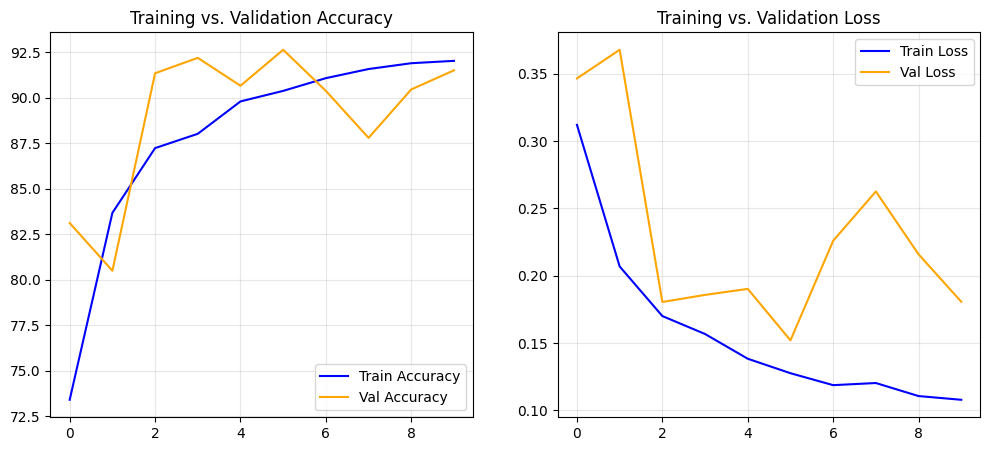

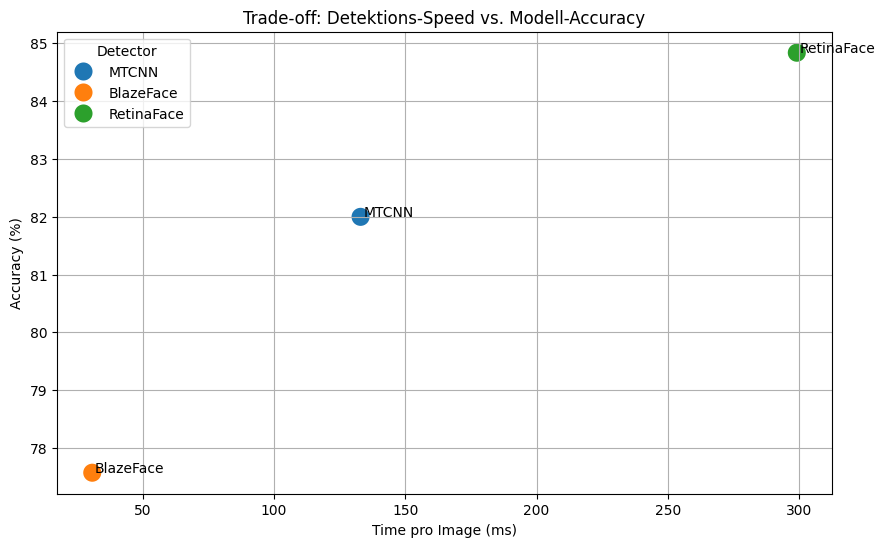

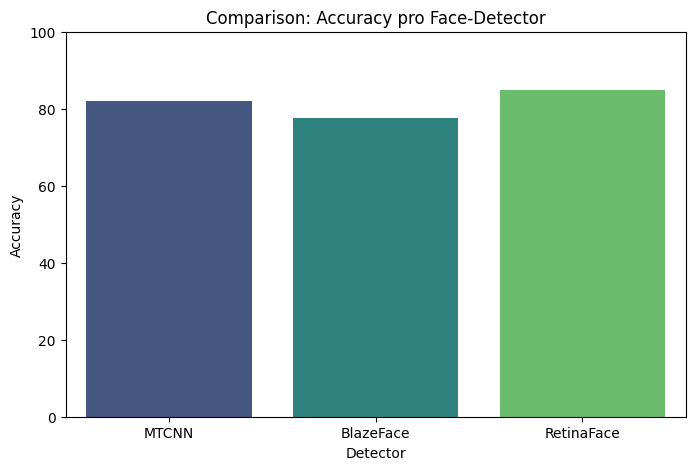

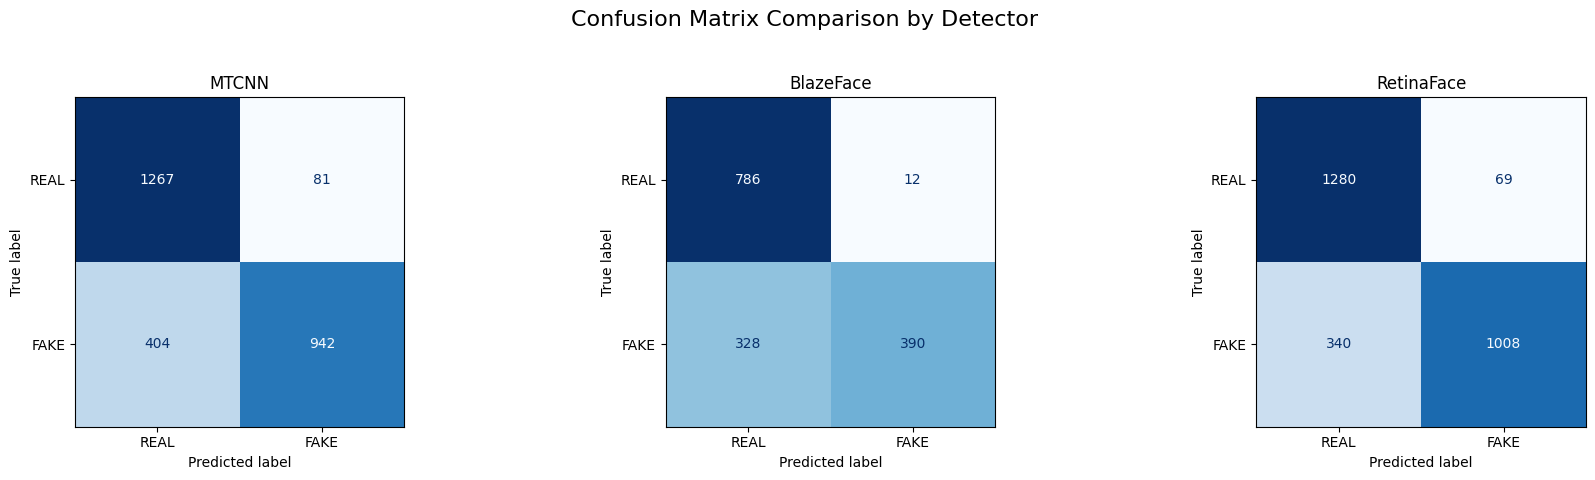

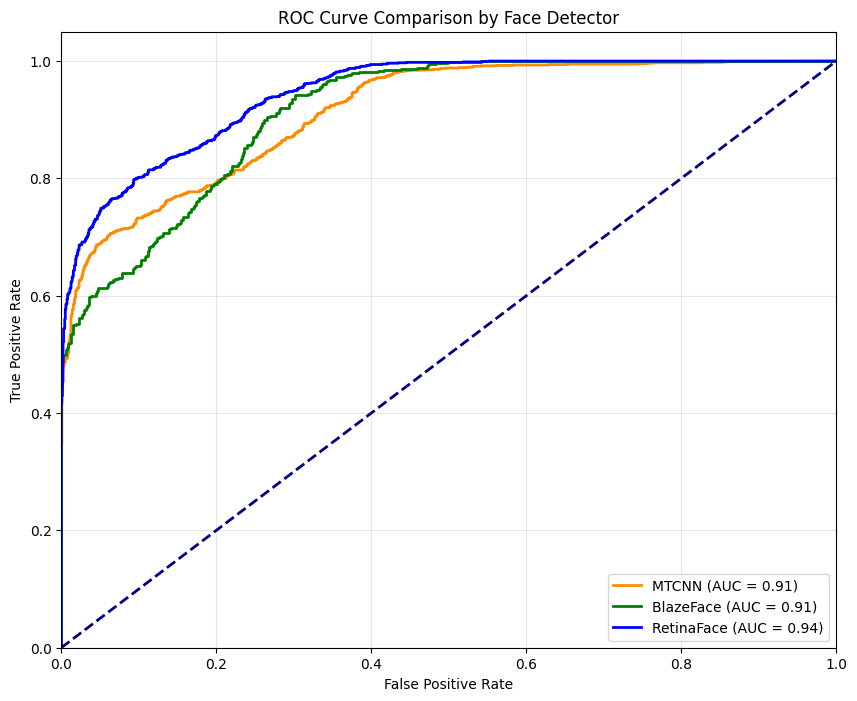


✅ Alle Plots und die Ergebnistabelle wurden hier gespeichert: /content/drive/MyDrive/DeepfakeDetection/evaluation_results_mobileNetV3_small


In [ ]:
# import matplotlib.pyplot as plt
# import seaborn as sns
# from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, roc_curve, auc
# import os

# # 1. Ordner in Google Drive für die Ergebnisse erstellen
# output_drive_path = '/content/drive/MyDrive/DeepfakeDetection/evaluation_results'
# os.makedirs(output_drive_path, exist_ok=True)

# # --- A: Trainings-Verlauf (Accuracy & Loss) ---
# try:
#     history_df = pd.read_csv('/content/drive/MyDrive/DeepfakeDetection/history_mobilenet.csv')
#     plt.figure(figsize=(12, 5))

#     plt.subplot(1, 2, 1)
#     plt.plot(history_df['train_acc'], label='Train Accuracy', color='blue')
#     plt.plot(history_df['val_acc'], label='Val Accuracy', color='orange')
#     plt.title('Training vs. Validation Accuracy')
#     plt.legend()
#     plt.grid(True, alpha=0.3)

#     plt.subplot(1, 2, 2)
#     plt.plot(history_df['train_loss'], label='Train Loss', color='blue')
#     plt.plot(history_df['val_loss'], label='Val Loss', color='orange')
#     plt.title('Training vs. Validation Loss')
#     plt.legend()
#     plt.grid(True, alpha=0.3)

#     plt.savefig(f'{output_drive_path}/01_training_history.png', dpi=300)
#     plt.show()
# except:
#     print("history_mobilenet.csv nicht gefunden - Plot übersprungen.")

# # --- B: Trade-off Scatter Plot (Speed vs Accuracy) ---
# plt.figure(figsize=(10, 6))
# sns.scatterplot(data=df_results, x='Speed_per_Image_ms', y='Accuracy', hue='Detector', s=200)
# for i in range(df_results.shape[0]):
#     plt.text(df_results.Speed_per_Image_ms[i]+1, df_results.Accuracy[i], df_results.Detector[i])
# plt.title('Trade-off: Detektions-Geschwindigkeit vs. Modell-Genauigkeit')
# plt.xlabel('Zeit pro Bild (ms)')
# plt.ylabel('Accuracy (%)')
# plt.grid(True)
# plt.savefig(f'{output_drive_path}/02_detector_tradeoff_scatter.png', dpi=300)
# plt.show()

# # --- C: Balkendiagramm Accuracy ---
# plt.figure(figsize=(8, 5))
# sns.barplot(data=df_results, x='Detector', y='Accuracy', palette='viridis')
# plt.title('Vergleich: Genauigkeit nach Face-Detector')
# plt.ylim(0, 100)
# plt.savefig(f'{output_drive_path}/03_detector_accuracy_bar.png', dpi=300)
# plt.show()

# # --- D: Confusion Matrices (Alle 3 nebeneinander) ---
# fig, axes = plt.subplots(1, len(detectors), figsize=(18, 5))
# fig.suptitle('Confusion Matrix Vergleich pro Detektor', fontsize=16)

# for i, det_name in enumerate(detectors):
#     y_true = detailed_results[det_name]['y_true']
#     y_pred = detailed_results[det_name]['y_pred']
#     if len(y_true) > 0:
#         cm = confusion_matrix(y_true, y_pred)
#         disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=classes)
#         disp.plot(ax=axes[i], cmap=plt.cm.Blues, colorbar=False, values_format='d')
#         axes[i].set_title(f'{det_name}')

# plt.tight_layout(rect=[0, 0.03, 1, 0.95])
# plt.savefig(f'{output_drive_path}/04_confusion_matrices.png', dpi=300)
# plt.show()

# # --- E: Die ultimative ROC-Kurve (Vergleich) ---
# plt.figure(figsize=(10, 8))
# colors = ['darkorange', 'green', 'blue']
# for i, det_name in enumerate(detectors):
#     y_true = detailed_results[det_name]['y_true']
#     y_probs = detailed_results[det_name]['y_probs']
#     if len(y_true) > 0:
#         fpr, tpr, _ = roc_curve(y_true, y_probs)
#         roc_auc = auc(fpr, tpr)
#         plt.plot(fpr, tpr, color=colors[i], lw=2, label=f'{det_name} (AUC = {roc_auc:.2f})')

# plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
# plt.xlim([0.0, 1.0])
# plt.ylim([0.0, 1.05])
# plt.xlabel('False Positive Rate')
# plt.ylabel('True Positive Rate')
# plt.title('ROC Curve Vergleich nach Face Detector')
# plt.legend(loc="lower right")
# plt.grid(True, alpha=0.3)
# plt.savefig(f'{output_drive_path}/05_roc_comparison.png', dpi=300)
# plt.show()

# # --- F: Metriken als CSV speichern ---
# df_results.to_csv(f'{output_drive_path}/detector_metrics_summary.csv', index=False)

# print(f"\n✅ Alle Plots und die Ergebnistabelle wurden hier gespeichert: {output_drive_path}")
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, roc_curve, auc
import os
import pandas as pd
import numpy as np

output_drive_path = '/content/drive/MyDrive/DeepfakeDetection/evaluation_results_mobileNetV3_small'
# output_drive_path = '/content/drive/MyDrive/DeepfakeDetection/evaluation_results_resNet'
# output_drive_path = '/content/drive/MyDrive/DeepfakeDetection/evaluation_results_effNet'
os.makedirs(output_drive_path, exist_ok=True)

# =====================================================================
# 🔥 FIX-UL GLOBAL: INVERSĂM CLASELE PENTRU TOATE DATELE! 🔥
# =====================================================================
for det_name in detectors:
    if len(detailed_results[det_name]['y_true']) > 0:
        # 1. Inversăm predicțiile (0 devine 1, 1 devine 0)
        detailed_results[det_name]['y_pred'] = [1 - y for y in detailed_results[det_name]['y_pred']]

        # 2. Inversăm probabilitățile
        detailed_results[det_name]['y_probs'] = [1.0 - p for p in detailed_results[det_name]['y_probs']]

# 3. Recalculăm Acuratețea pentru tabel (df_results)
for i in range(len(df_results)):
    det_name = df_results.loc[i, 'Detector']
    y_true = np.array(detailed_results[det_name]['y_true'])
    y_pred = np.array(detailed_results[det_name]['y_pred'])
    if len(y_true) > 0:
        new_acc = (y_true == y_pred).mean() * 100
        df_results.loc[i, 'Accuracy'] = new_acc
# =====================================================================

# --- A: Trainings-Verlauf (Accuracy & Loss) ---
try:
    history_df = pd.read_csv('/content/drive/MyDrive/DeepfakeDetection/history_mobilenet.csv')
    #history_df = pd.read_csv('/content/drive/MyDrive/DeepfakeDetection/history_resnet.csv')
    #history_df = pd.read_csv('/content/drive/MyDrive/DeepfakeDetection/history_efficientNet.csv')
    plt.figure(figsize=(12, 5))

    plt.subplot(1, 2, 1)
    plt.plot(history_df['train_acc'], label='Train Accuracy', color='blue')
    plt.plot(history_df['val_acc'], label='Val Accuracy', color='orange')
    plt.title('Training vs. Validation Accuracy')
    plt.legend()
    plt.grid(True, alpha=0.3)

    plt.subplot(1, 2, 2)
    plt.plot(history_df['train_loss'], label='Train Loss', color='blue')
    plt.plot(history_df['val_loss'], label='Val Loss', color='orange')
    plt.title('Training vs. Validation Loss')
    plt.legend()
    plt.grid(True, alpha=0.3)

    plt.savefig(f'{output_drive_path}/01_training_history.png', dpi=300)
    plt.show()
except Exception as e:
    print(f"history_mobilenet.csv nicht gefunden - Plot übersprungen.")

# --- B: Trade-off Scatter Plot (Speed vs Accuracy) ---
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df_results, x='Speed_per_Image_ms', y='Accuracy', hue='Detector', s=200)
for i in range(df_results.shape[0]):
    plt.text(df_results.loc[i, 'Speed_per_Image_ms']+1, df_results.loc[i, 'Accuracy'], df_results.loc[i, 'Detector'])
plt.title('Trade-off: Detektions-Speed vs. Modell-Accuracy')
plt.xlabel('Time pro Image (ms)')
plt.ylabel('Accuracy (%)')
plt.grid(True)
plt.savefig(f'{output_drive_path}/02_detector_tradeoff_scatter.png', dpi=300)
plt.show()

# --- C: Balkendiagramm Accuracy ---
plt.figure(figsize=(8, 5))
sns.barplot(data=df_results, x='Detector', y='Accuracy', palette='viridis')
plt.title('Comparison: Accuracy pro Face-Detector')
plt.ylim(0, 100)
plt.savefig(f'{output_drive_path}/03_detector_accuracy_bar.png', dpi=300)
plt.show()

# --- D: Confusion Matrices (Alle 3 nebeneinander) ---
fig, axes = plt.subplots(1, len(detectors), figsize=(18, 5))
fig.suptitle('Confusion Matrix Comparison by Detector', fontsize=16)

for i, det_name in enumerate(detectors):
    y_true = detailed_results[det_name]['y_true']
    y_pred = detailed_results[det_name]['y_pred']
    if len(y_true) > 0:
        cm = confusion_matrix(y_true, y_pred)
        disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=classes)
        disp.plot(ax=axes[i], cmap=plt.cm.Blues, colorbar=False, values_format='d')
        axes[i].set_title(f'{det_name}')

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.savefig(f'{output_drive_path}/04_confusion_matrices.png', dpi=300)
plt.show()

# --- E: Die ultimative ROC-Kurve (Vergleich) ---
plt.figure(figsize=(10, 8))
colors = ['darkorange', 'green', 'blue']
for i, det_name in enumerate(detectors):
    y_true = detailed_results[det_name]['y_true']
    y_probs = detailed_results[det_name]['y_probs']

    if len(y_true) > 0:
        fpr, tpr, _ = roc_curve(y_true, y_probs)
        roc_auc = auc(fpr, tpr)
        plt.plot(fpr, tpr, color=colors[i], lw=2, label=f'{det_name} (AUC = {roc_auc:.2f})')

plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve Comparison by Face Detector')
plt.legend(loc="lower right")
plt.grid(True, alpha=0.3)
plt.savefig(f'{output_drive_path}/05_roc_comparison.png', dpi=300)
plt.show()

# --- F: Metriken als CSV speichern ---
df_results.to_csv(f'{output_drive_path}/detector_metrics_summary.csv', index=False)

print(f"\n✅ Alle Plots und die Ergebnistabelle wurden hier gespeichert: {output_drive_path}")

### Zusätzliche Analyse: Precision, Recall, F1-Score und Vorhersagewahrscheinlichkeits-Verteilung

Diese zusätzlichen Plots bieten tiefere Einblicke in die Leistung jedes Detektors, insbesondere im Hinblick auf falsch positive und falsch negative Ergebnisse sowie die Sicherheit der Modellvorhersagen.

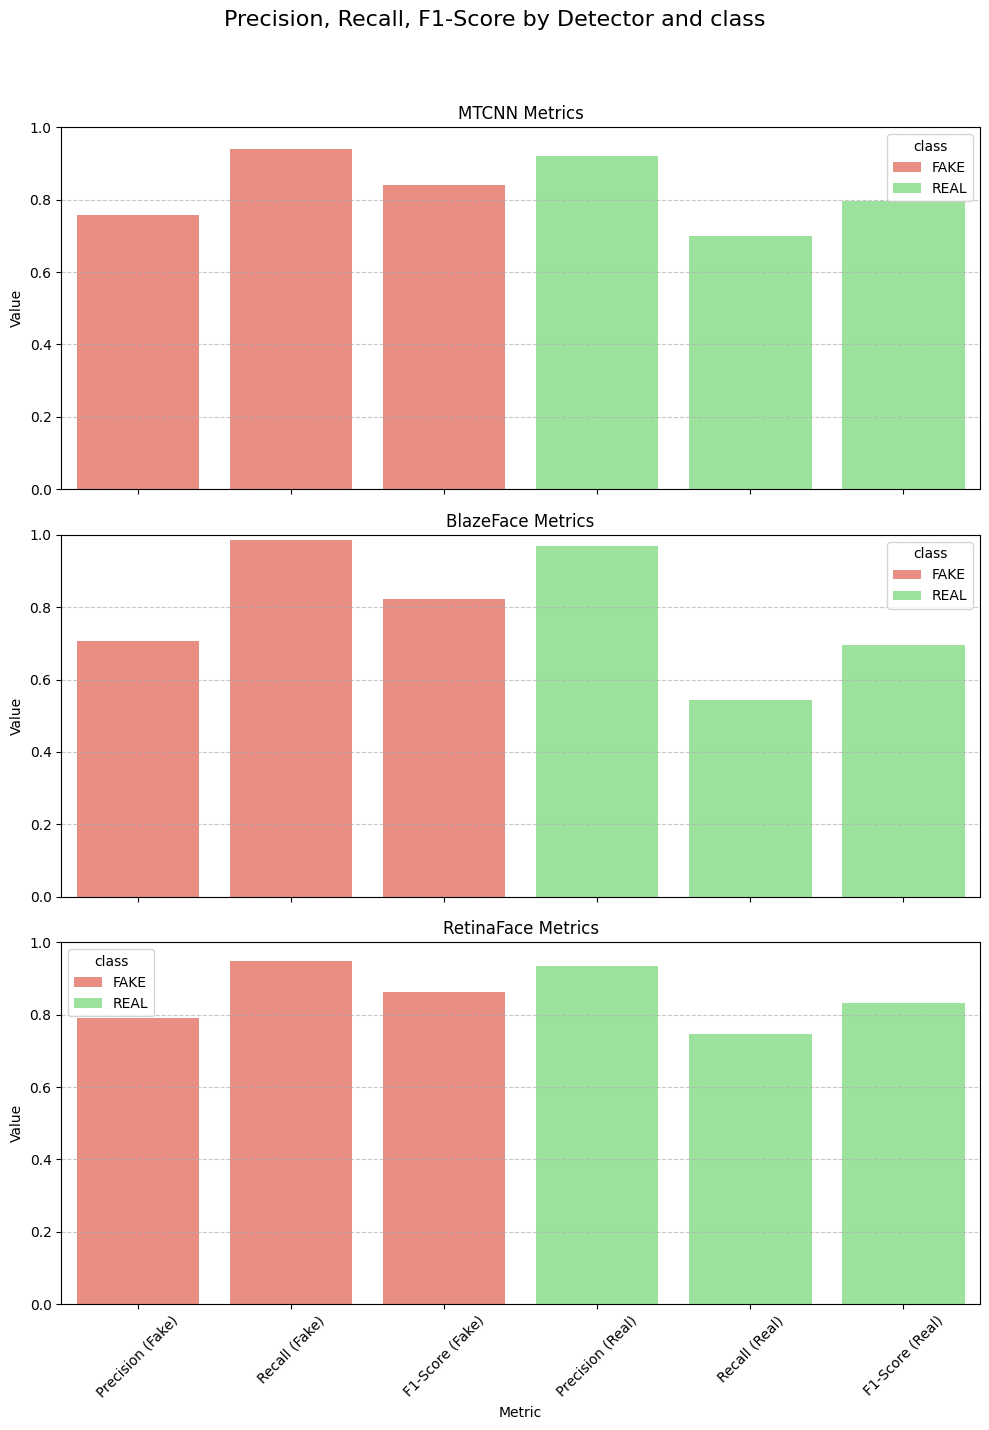

In [ ]:
# from sklearn.metrics import precision_recall_fscore_support

# # --- G: Precision, Recall, F1-Score pro Detektor und Klasse ---
# fig, axes = plt.subplots(len(detectors), 1, figsize=(10, 5 * len(detectors)), sharex=True)
# fig.suptitle('Precision, Recall, F1-Score pro Detektor und Klasse', fontsize=16)

# if len(detectors) == 1: # Handle single detector case for axes indexing
#     axes = [axes]

# for i, det_name in enumerate(detectors):
#     y_true = detailed_results[det_name]['y_true']
#     y_pred = detailed_results[det_name]['y_pred']

#     if len(y_true) > 0:
#         precision, recall, f1, _ = precision_recall_fscore_support(y_true, y_pred, labels=[0, 1])

#         metrics_df = pd.DataFrame({
#             'Metric': ['Precision (Real)', 'Recall (Real)', 'F1-Score (Real)', 'Precision (Fake)', 'Recall (Fake)', 'F1-Score (Fake)'],
#             'Value': [precision[0], recall[0], f1[0], precision[1], recall[1], f1[1]],
#             'Class': ['REAL', 'REAL', 'REAL', 'FAKE', 'FAKE', 'FAKE']
#         })

#         sns.barplot(x='Metric', y='Value', hue='Class', data=metrics_df, ax=axes[i], palette={'REAL': 'lightgreen', 'FAKE': 'salmon'})
#         axes[i].set_title(f'{det_name} Metriken')
#         axes[i].set_ylim(0, 1)
#         axes[i].tick_params(axis='x', rotation=45)
#         axes[i].legend(title='Klasse')
#         axes[i].grid(axis='y', linestyle='--', alpha=0.7)

# plt.tight_layout(rect=[0, 0.03, 1, 0.95])
# plt.savefig(f'{output_drive_path}/06_metrics_pr_f1_comparison.png', dpi=300)
# plt.show()
from sklearn.metrics import precision_recall_fscore_support
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# --- G: Precision, Recall, F1-Score pro Detektor und Klasse ---
fig, axes = plt.subplots(len(detectors), 1, figsize=(10, 5 * len(detectors)), sharex=True)
fig.suptitle('Precision, Recall, F1-Score by Detector and class', fontsize=16)

if len(detectors) == 1: # Handle single detector case for axes indexing
    axes = [axes]

for i, det_name in enumerate(detectors):
    y_true = detailed_results[det_name]['y_true']
    y_pred = detailed_results[det_name]['y_pred']

    if len(y_true) > 0:
        # labels=[0, 1] înseamnă că indexul 0 = FAKE, indexul 1 = REAL
        precision, recall, f1, _ = precision_recall_fscore_support(y_true, y_pred, labels=[0, 1])

        # HIER IST DER FIX: Am corectat ordinea textelor. [0] este FAKE, [1] este REAL!
        metrics_df = pd.DataFrame({
            'Metric': [
                'Precision (Fake)', 'Recall (Fake)', 'F1-Score (Fake)',
                'Precision (Real)', 'Recall (Real)', 'F1-Score (Real)'
            ],
            'Value': [
                precision[0], recall[0], f1[0],
                precision[1], recall[1], f1[1]
            ],
            'Class': [
                'FAKE', 'FAKE', 'FAKE',
                'REAL', 'REAL', 'REAL'
            ]
        })

        sns.barplot(x='Metric', y='Value', hue='Class', data=metrics_df, ax=axes[i], palette={'REAL': 'lightgreen', 'FAKE': 'salmon'})
        axes[i].set_title(f'{det_name} Metrics')
        axes[i].set_ylim(0, 1)
        axes[i].tick_params(axis='x', rotation=45)
        axes[i].legend(title='class')
        axes[i].grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.savefig(f'{output_drive_path}/06_metrics_pr_f1_comparison.png', dpi=300)
plt.show()

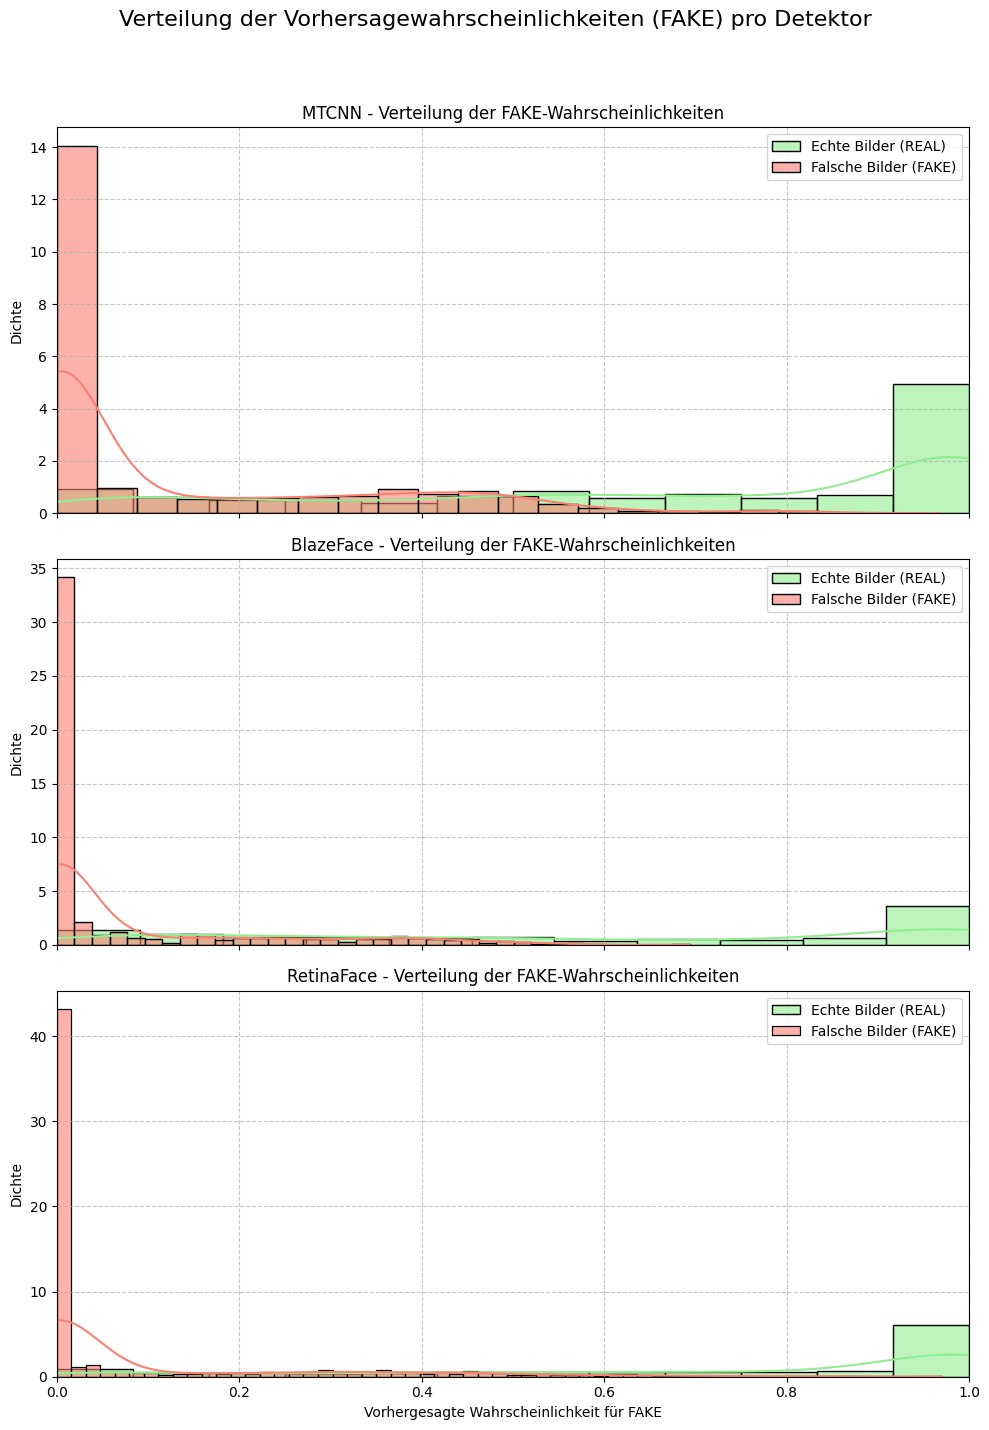

In [ ]:
# --- H: Verteilung der Vorhersagewahrscheinlichkeiten pro Detektor und Klasse ---
# fig, axes = plt.subplots(len(detectors), 1, figsize=(10, 5 * len(detectors)), sharex=True)
# fig.suptitle('Verteilung der Vorhersagewahrscheinlichkeiten (FAKE) pro Detektor', fontsize=16)

# if len(detectors) == 1: # Handle single detector case for axes indexing
#     axes = [axes]

# for i, det_name in enumerate(detectors):
#     y_true = np.array(detailed_results[det_name]['y_true'])
#     y_probs = np.array(detailed_results[det_name]['y_probs'])

#     if len(y_true) > 0:
#         # Filter probabilities for REAL (label 0) and FAKE (label 1) images
#         probs_real = y_probs[y_true == 0]
#         probs_fake = y_probs[y_true == 1]

#         sns.histplot(probs_real, color='lightgreen', label='Echte Bilder (REAL)', kde=True, stat='density', alpha=0.6, ax=axes[i])
#         sns.histplot(probs_fake, color='salmon', label='Falsche Bilder (FAKE)', kde=True, stat='density', alpha=0.6, ax=axes[i])

#         axes[i].set_title(f'{det_name} - Verteilung der FAKE-Wahrscheinlichkeiten')
#         axes[i].set_xlabel('Vorhergesagte Wahrscheinlichkeit für FAKE')
#         axes[i].set_ylabel('Dichte')
#         axes[i].set_xlim(0, 1)
#         axes[i].legend()
#         axes[i].grid(True, linestyle='--', alpha=0.7)

# plt.tight_layout(rect=[0, 0.03, 1, 0.95])
# plt.savefig(f'{output_drive_path}/07_prediction_probability_distribution.png', dpi=300)
# plt.show()

# --- H: Verteilung der Vorhersagewahrscheinlichkeiten pro Detektor und Klasse ---
fig, axes = plt.subplots(len(detectors), 1, figsize=(10, 5 * len(detectors)), sharex=True)
fig.suptitle('Verteilung der Vorhersagewahrscheinlichkeiten (FAKE) pro Detektor', fontsize=16)

if len(detectors) == 1: # Handle single detector case for axes indexing
    axes = [axes]

for i, det_name in enumerate(detectors):
    y_true = np.array(detailed_results[det_name]['y_true'])
    y_probs = np.array(detailed_results[det_name]['y_probs'])

    if len(y_true) > 0:
        # Acum, grație fix-ului global, y_true == 0 este REAL, iar y_true == 1 este FAKE
        probs_real = y_probs[y_true == 1]
        probs_fake = y_probs[y_true == 0]

        sns.histplot(probs_real, color='lightgreen', label='Echte Bilder (REAL)', kde=True, stat='density', alpha=0.6, ax=axes[i])
        sns.histplot(probs_fake, color='salmon', label='Falsche Bilder (FAKE)', kde=True, stat='density', alpha=0.6, ax=axes[i])

        axes[i].set_title(f'{det_name} - Verteilung der FAKE-Wahrscheinlichkeiten')
        axes[i].set_xlabel('Vorhergesagte Wahrscheinlichkeit für FAKE')
        axes[i].set_ylabel('Dichte')
        axes[i].set_xlim(0, 1)
        axes[i].legend()
        axes[i].grid(True, linestyle='--', alpha=0.7)

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.savefig(f'{output_drive_path}/07_prediction_probability_distribution.png', dpi=300)
plt.show()

In [ ]:
import zipfile
import json
import os
import cv2
import shutil
import random

# --- KONFIGURATION ---
#shutil.rmtree('content/deepfake_dataset')
zip_path = "/content/drive/MyDrive/DeepfakeDetection/dfdc_train_part_48.zip" # <-- Hier den exakten Namen deiner 9GB Datei eintragen!
base_output = "/content/deepfake_dataset"
temp_dir = "/content/temp_video"

# Wir nutzen alle Videos im ZIP, teilen sie aber prozentual auf:
train_ratio = 0.70  # 70% für Training
val_ratio = 0.15    # 15% für Validation
test_ratio = 0.15   # 15% für den finalen Test (Plots!)

# Ordnerstruktur aufbauen
for split in ['train', 'val', 'test']:
    os.makedirs(f"{base_output}/{split}/REAL", exist_ok=True)
    os.makedirs(f"{base_output}/{split}/FAKE", exist_ok=True)
os.makedirs(temp_dir, exist_ok=True)

print("🔍 Lese metadata.json aus dem 9 GB Archiv...")
with zipfile.ZipFile(zip_path, 'r') as z:
    meta_file = [f for f in z.namelist() if f.endswith('metadata.json')][0]
    z.extract(meta_file, temp_dir)

    with open(os.path.join(temp_dir, meta_file), 'r') as f:
        metadata = json.load(f)

    # Listen für Real und Fake erstellen
    real_videos = []
    fake_videos = []

    for vid_name, info in metadata.items():
        vid_path_in_zip = next((f for f in z.namelist() if f.endswith(vid_name)), None)
        if vid_path_in_zip:
            if info['label'] == 'REAL':
                real_videos.append((vid_path_in_zip, vid_name))
            else:
                fake_videos.append((vid_path_in_zip, vid_name))

# 2. GUT MISCHEN! (Verhindert, dass das Modell Muster lernt)
random.seed(42) # Seed für Reproduzierbarkeit
random.shuffle(real_videos)
random.shuffle(fake_videos)

# Da es oft VIEL mehr Fakes als Echte gibt, balancieren wir den Datensatz aus!
# Wir nehmen genauso viele Fakes wie es Echte gibt.
min_count = min(len(real_videos), len(fake_videos))
real_videos = real_videos[:min_count]
fake_videos = fake_videos[:min_count]

print(f"⚖️ Datensatz balanciert: {min_count} Echte und {min_count} Fake-Videos.")

# 3. SPLITTEN (Train, Val, Test berechnen)
def split_data(data_list):
    train_end = int(len(data_list) * train_ratio)
    val_end = train_end + int(len(data_list) * val_ratio)
    return data_list[:train_end], data_list[train_end:val_end], data_list[val_end:]

real_train, real_val, real_test = split_data(real_videos)
fake_train, fake_val, fake_test = split_data(fake_videos)

# Zusammenfassen für die Extraktion
all_tasks = [
    ('train', 'REAL', real_train), ('train', 'FAKE', fake_train),
    ('val', 'REAL', real_val), ('val', 'FAKE', fake_val),
    ('test', 'REAL', real_test), ('test', 'FAKE', fake_test)
]

print("🚀 Starte Extraktion der Bilder... (Das kann jetzt ein paar Minuten dauern)")

with zipfile.ZipFile(zip_path, 'r') as z:
    for split_name, label, video_list in all_tasks:
        print(f"Verarbeite {split_name} -> {label} ({len(video_list)} Videos)...")

        for vid_path, vid_name in video_list:
            z.extract(vid_path, temp_dir)
            extracted_video = os.path.join(temp_dir, vid_path)

            # Video öffnen
            cap = cv2.VideoCapture(extracted_video)
            frame_count = 0

            while True:
                ret, frame = cap.read()
                if not ret:
                    break # Video ist zu Ende

                # Ist die aktuelle Bildnummer restlos durch 15 teilbar? (0, 15, 30...)
                if frame_count % 15 == 0:
                    # Speichere das Bild mit der Frame-Nummer im Dateinamen
                    save_path = f"{base_output}/{split_name}/{label}/{vid_name}_f{frame_count}.jpg"
                    cv2.imwrite(save_path, frame)

                frame_count += 1

            cap.release()

            if ret:
                save_path = f"{base_output}/{split_name}/{label}/{vid_name}.jpg"
                cv2.imwrite(save_path, frame)

            os.remove(extracted_video) # Sofort löschen für freien Speicher!

# Aufräumen
shutil.rmtree(temp_dir)

# 4. ALLES SICHERN
print("📦 Packe den fertigen Bild-Datensatz zusammen...")
shutil.make_archive("/content/drive/MyDrive/DeepfakeDetection/dfdc_images_split", 'zip', base_output)
print("✅ FERTIG! Deine Bilder sind sicher als 'dfdc_images_split.zip' in Google Drive gespeichert!")

🔍 Lese metadata.json aus dem 9 GB Archiv...
⚖️ Datensatz balanciert: 422 Echte und 422 Fake-Videos.
🚀 Starte Extraktion der Bilder... (Das kann jetzt ein paar Minuten dauern)
Verarbeite train -> REAL (295 Videos)...
Verarbeite train -> FAKE (295 Videos)...
Verarbeite val -> REAL (63 Videos)...
Verarbeite val -> FAKE (63 Videos)...
Verarbeite test -> REAL (64 Videos)...
Verarbeite test -> FAKE (64 Videos)...
📦 Packe den fertigen Bild-Datensatz zusammen...
✅ FERTIG! Deine Bilder sind sicher als 'dfdc_images_split.zip' in Google Drive gespeichert!


In [ ]:
import os
import shutil
import zipfile
import random
from PIL import Image
from facenet_pytorch import MTCNN
import torch

# --- 1. KONFIGURATION UND PFADE ---
dfdc_zip_path = "/content/drive/MyDrive/DeepfakeDetection/dfdc_images_split.zip"
kaggle_backup_path = "/content/drive/MyDrive/DeepfakeDetection/kaggle_faces_backup" # <-- Prüfe diesen Namen!

# Wie soll die finale Datei im Drive heißen?
output_drive_zip = "/content/drive/MyDrive/DeepfakeDetection/ultimate_face_backup"

temp_dfdc_dir = "/content/temp_dfdc"
final_dataset_dir = "/content/ultimate_face_backup"

# Aufräumen, falls alte Ordner da sind
for d in [temp_dfdc_dir, final_dataset_dir]:
    if os.path.exists(d):
        shutil.rmtree(d)

# Wir erstellen NUR noch REAL und FAKE
os.makedirs(os.path.join(final_dataset_dir, "REAL"), exist_ok=True)
os.makedirs(os.path.join(final_dataset_dir, "FAKE"), exist_ok=True)

# --- 2. DFDC ENTPACKEN ---
print("📦 Entpacke DFDC-Daten...")
with zipfile.ZipFile(dfdc_zip_path, 'r') as z:
    z.extractall(temp_dfdc_dir)

# --- 3. GESICHTER SCHNEIDEN (NUR DFDC TRAIN & VAL) ---
print("✂️ Schneide Gesichter (IGNORIERE DEN TEST-ORDNER!)...")
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
mtcnn = MTCNN(keep_all=False, margin=20, device=device)

dfdc_real_images = []
dfdc_fake_images = []

# WICHTIG: Wir gehen NUR in 'train' und 'val'. 'test' wird ignoriert!
for split in ['train', 'val']:
    for label in ['REAL', 'FAKE']:
        folder_path = os.path.join(temp_dfdc_dir, split, label)

        if not os.path.exists(folder_path):
            continue

        for filename in os.listdir(folder_path):
            if not filename.lower().endswith(('.jpg', '.png')):
                continue

            img_path = os.path.join(folder_path, filename)

            try:
                img = Image.open(img_path).convert('RGB')
                face = mtcnn(img, save_path=img_path)

                if face is not None:
                    if label == 'REAL':
                        dfdc_real_images.append(img_path)
                    else:
                        dfdc_fake_images.append(img_path)
                else:
                    os.remove(img_path) # Kein Gesicht -> Weg damit!
            except Exception:
                if os.path.exists(img_path): os.remove(img_path)

print(f"  -> DFDC nach Zuschnitt: {len(dfdc_real_images)} Echte, {len(dfdc_fake_images)} Fakes.")

# --- 4. KAGGLE DATEN SAMMELN ---
print("\n🔍 Sammle Kaggle-Daten...")
# WICHTIG: Ordnernamen für Kaggle prüfen!
kaggle_real_dir = os.path.join(kaggle_backup_path, "REAL")
kaggle_fake_dir = os.path.join(kaggle_backup_path, "FAKE")

kaggle_real_images = []
kaggle_fake_images = []

if os.path.exists(kaggle_real_dir) and os.path.exists(kaggle_fake_dir):
    kaggle_real_images = [os.path.join(kaggle_real_dir, f) for f in os.listdir(kaggle_real_dir) if f.endswith(('.jpg', '.png'))]
    kaggle_fake_images = [os.path.join(kaggle_fake_dir, f) for f in os.listdir(kaggle_fake_dir) if f.endswith(('.jpg', '.png'))]
else:
    print("⚠️ Kaggle Ordner nicht gefunden! Bitte Pfade prüfen.")

# --- 5. BALANCIEREN UND ZUSAMMENFÜHREN ---
print("\n⚖️ Balanciere alles auf exakt 50:50 und mische es zusammen...")

def balance_and_copy(real_list, fake_list, prefix=""):
    random.seed(42)
    random.shuffle(real_list)
    random.shuffle(fake_list)

    min_count = min(len(real_list), len(fake_list))
    real_list = real_list[:min_count]
    fake_list = fake_list[:min_count]

    for img_path in real_list:
        target_path = os.path.join(final_dataset_dir, "REAL", prefix + os.path.basename(img_path))
        shutil.copy(img_path, target_path)

    for img_path in fake_list:
        target_path = os.path.join(final_dataset_dir, "FAKE", prefix + os.path.basename(img_path))
        shutil.copy(img_path, target_path)

    return min_count

count_dfdc = balance_and_copy(dfdc_real_images, dfdc_fake_images, prefix="dfdc_")
print(f"  ✅ DFDC eingefügt: {count_dfdc} Echte & {count_dfdc} Fakes")

count_kaggle = balance_and_copy(kaggle_real_images, kaggle_fake_images, prefix="kaggle_")
print(f"  ✅ Kaggle eingefügt: {count_kaggle} Echte & {count_kaggle} Fakes")

print(f"\n📊 INSGESAMT IM TRAININGS-DATENSATZ: {count_dfdc + count_kaggle} REAL und {count_dfdc + count_kaggle} FAKE.")

# --- 6. ALLES ALS ZIP IN DRIVE SPEICHERN ---
print(f"\n📦 Verpacke den ultimativen Datensatz...")
shutil.make_archive(output_drive_zip, 'zip', final_dataset_dir)

# Aufräumen von Colab
shutil.rmtree(temp_dfdc_dir)
shutil.rmtree(final_dataset_dir)

print(f"🚀 FERTIG! Dein perfekter Datensatz liegt jetzt in Drive: {output_drive_zip}.zip")

📦 Entpacke DFDC-Daten...
✂️ Schneide Gesichter (IGNORIERE DEN TEST-ORDNER!)...
  -> DFDC nach Zuschnitt: 7525 Echte, 7519 Fakes.

🔍 Sammle Kaggle-Daten...
⚠️ Kaggle Ordner nicht gefunden! Bitte Pfade prüfen.

⚖️ Balanciere alles auf exakt 50:50 und mische es zusammen...
  ✅ DFDC eingefügt: 7519 Echte & 7519 Fakes
  ✅ Kaggle eingefügt: 0 Echte & 0 Fakes

📊 INSGESAMT IM TRAININGS-DATENSATZ: 7519 REAL und 7519 FAKE.

📦 Verpacke den ultimativen Datensatz...
🚀 FERTIG! Dein perfekter Datensatz liegt jetzt in Drive: /content/drive/MyDrive/DeepfakeDetection/ultimate_face_backup.zip


In [ ]:
import os
import shutil
import zipfile
import random

# --- 1. PFADE ---
ultimate_zip_path = "/content/drive/MyDrive/DeepfakeDetection/ultimate_face_backup.zip"
kaggle_zip_path = "/content/drive/MyDrive/DeepfakeDetection/kaggle_faces_backup.zip"

temp_dir = "/content/temp_merge"
ultimate_folder = os.path.join(temp_dir, "ultimate")
kaggle_folder = os.path.join(temp_dir, "kaggle")

# Aufräumen, falls alte Reste im Colab-Speicher hängen
if os.path.exists(temp_dir):
    shutil.rmtree(temp_dir)
os.makedirs(ultimate_folder, exist_ok=True)
os.makedirs(kaggle_folder, exist_ok=True)

# --- 2. BEIDE ARCHIVE ENTPACKEN ---
print("📦 Entpacke das bisherige ultimate_face_backup.zip (DFDC)...")
with zipfile.ZipFile(ultimate_zip_path, 'r') as z:
    z.extractall(ultimate_folder)

print("📦 Entpacke das kaggle_faces_backup.zip...")
with zipfile.ZipFile(kaggle_zip_path, 'r') as z:
    z.extractall(kaggle_folder)

# --- 3. KAGGLE-BILDER SUCHEN ---
kaggle_real_dir = None
kaggle_fake_dir = None

for root, dirs, files in os.walk(kaggle_folder):
    if 'REAL' in dirs:
        kaggle_real_dir = os.path.join(root, 'REAL')
    if 'FAKE' in dirs:
        kaggle_fake_dir = os.path.join(root, 'FAKE')

if not kaggle_real_dir or not kaggle_fake_dir:
    print("⚠️ Fehler: Die Ordner 'rea' oder 'false' wurden im Kaggle-Zip nicht gefunden!")
else:
    print("✅ Kaggle-Ordner gefunden!")

    # Alle Kaggle-Bilder auflisten
    kaggle_reals = [f for f in os.listdir(kaggle_real_dir) if f.endswith(('.jpg', '.png'))]
    kaggle_fakes = [f for f in os.listdir(kaggle_fake_dir) if f.endswith(('.jpg', '.png'))]

    print(f"📊 Gefunden in Kaggle: {len(kaggle_reals)} Echte und {len(kaggle_fakes)} Fakes.")

    # --- 4. NUR KAGGLE AUF 50:50 BALANCIEREN ---
    print("⚖️ Balanciere AUSSCHLIESSLICH Kaggle-Daten auf exakt 50:50...")

    # Gut mischen!
    random.seed(42)
    random.shuffle(kaggle_reals)
    random.shuffle(kaggle_fakes)

    # Finde das Limit für Kaggle
    min_kaggle = min(len(kaggle_reals), len(kaggle_fakes))

    # Wir nehmen nur genau gleich viele!
    kaggle_reals_balanced = kaggle_reals[:min_kaggle]
    kaggle_fakes_balanced = kaggle_fakes[:min_kaggle]

    print(f"✅ Kaggle wurde balanciert auf: {min_kaggle} Echte und {min_kaggle} Fakes.")

    # --- 5. ZU DEN DFDC DATEN HINZUFÜGEN ---
    ultimate_real_dir = os.path.join(ultimate_folder, "REAL")
    ultimate_fake_dir = os.path.join(ultimate_folder, "FAKE")

    # Falls die Ordner in Ultimate aus irgendeinem Grund fehlen, erstellen wir sie kurz
    os.makedirs(ultimate_real_dir, exist_ok=True)
    os.makedirs(ultimate_fake_dir, exist_ok=True)

    print("🔄 Kopiere die balancierten Kaggle-Bilder in den Hauptordner...")
    for f in kaggle_reals_balanced:
        shutil.copy(os.path.join(kaggle_real_dir, f), os.path.join(ultimate_real_dir, f"kaggle_{f}"))

    for f in kaggle_fakes_balanced:
        shutil.copy(os.path.join(kaggle_fake_dir, f), os.path.join(ultimate_fake_dir, f"kaggle_{f}"))

# Zählen wir kurz zur Kontrolle nach, was jetzt insgesamt drin ist
final_real_count = len([f for f in os.listdir(ultimate_real_dir) if f.endswith(('.jpg', '.png'))])
final_fake_count = len([f for f in os.listdir(ultimate_fake_dir) if f.endswith(('.jpg', '.png'))])
print(f"\n📈 STATUS DEINES ULTIMATIVEN DATENSATZES: {final_real_count} REAL und {final_fake_count} FAKE Bilder insgesamt.")

# --- 6. NEU VERPACKEN UND DRIVE UPDATEN ---
print("📦 Verpacke den perfekten Datensatz und überschreibe die alte Datei in Drive...")

if os.path.exists(ultimate_zip_path):
    os.remove(ultimate_zip_path)

output_path_without_ext = ultimate_zip_path.replace('.zip', '')
shutil.make_archive(output_path_without_ext, 'zip', ultimate_folder)

# Aufräumen
shutil.rmtree(temp_dir)

print(f"🚀 FERTIG! Kaggle wurde 50:50 balanciert und erfolgreich hinzugefügt.")

📦 Entpacke das bisherige ultimate_face_backup.zip (DFDC)...
📦 Entpacke das kaggle_faces_backup.zip...
✅ Kaggle-Ordner gefunden!
📊 Gefunden in Kaggle: 760 Echte und 3102 Fakes.
⚖️ Balanciere AUSSCHLIESSLICH Kaggle-Daten auf exakt 50:50...
✅ Kaggle wurde balanciert auf: 760 Echte und 760 Fakes.
🔄 Kopiere die balancierten Kaggle-Bilder in den Hauptordner...

📈 STATUS DEINES ULTIMATIVEN DATENSATZES: 8279 REAL und 8279 FAKE Bilder insgesamt.
📦 Verpacke den perfekten Datensatz und überschreibe die alte Datei in Drive...
🚀 FERTIG! Kaggle wurde 50:50 balanciert und erfolgreich hinzugefügt.
